# Gold Visualization

## Import libraries

In [1]:
import os
import sys
import pandas as pd
from scipy.stats import boxcox
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger, LogType
from visualizer.visualizer import Visualizer
from model.arima_model import ArimaModel
from utils.constants import *
from utils.enums import *
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *

## Initialize the Logger

In [2]:
my_logger = Logger(file_name=ARIMA_VISUALIZATION_LOG_FILE_BASE)

## Initialize the Visualizer

In [3]:
my_visualizer = Visualizer(logger=my_logger)

## Initialize the ArimaModel

In [4]:
arima_model = ArimaModel(logger=my_logger)

## Parameters

In [5]:
value_column_name = "#Passengers"

## Load data

In [6]:
df = pd.read_csv("AirPassengers.csv")
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


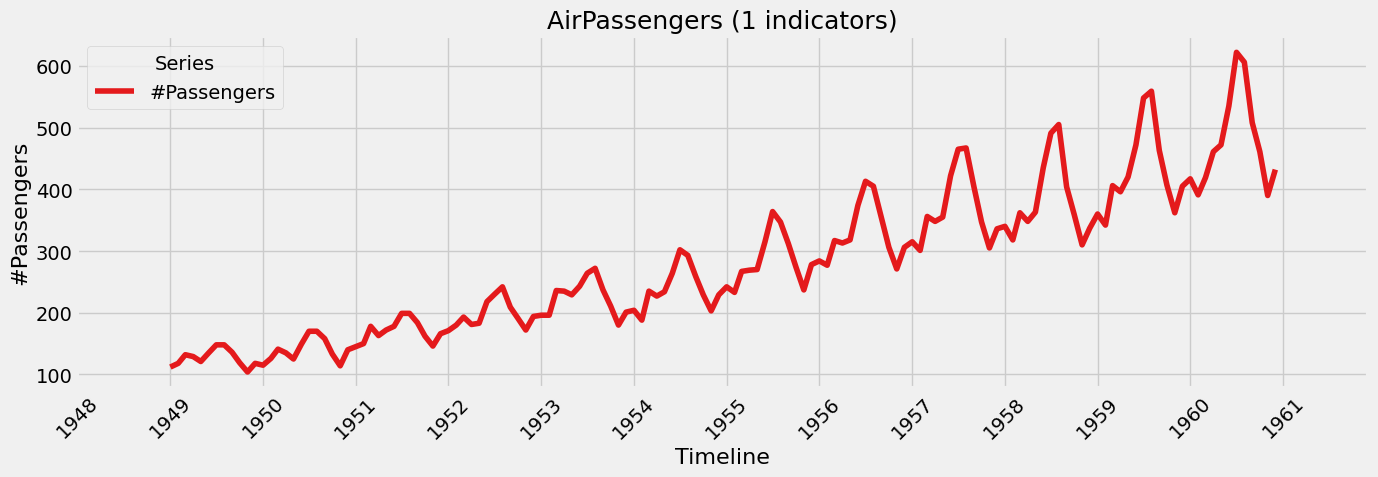

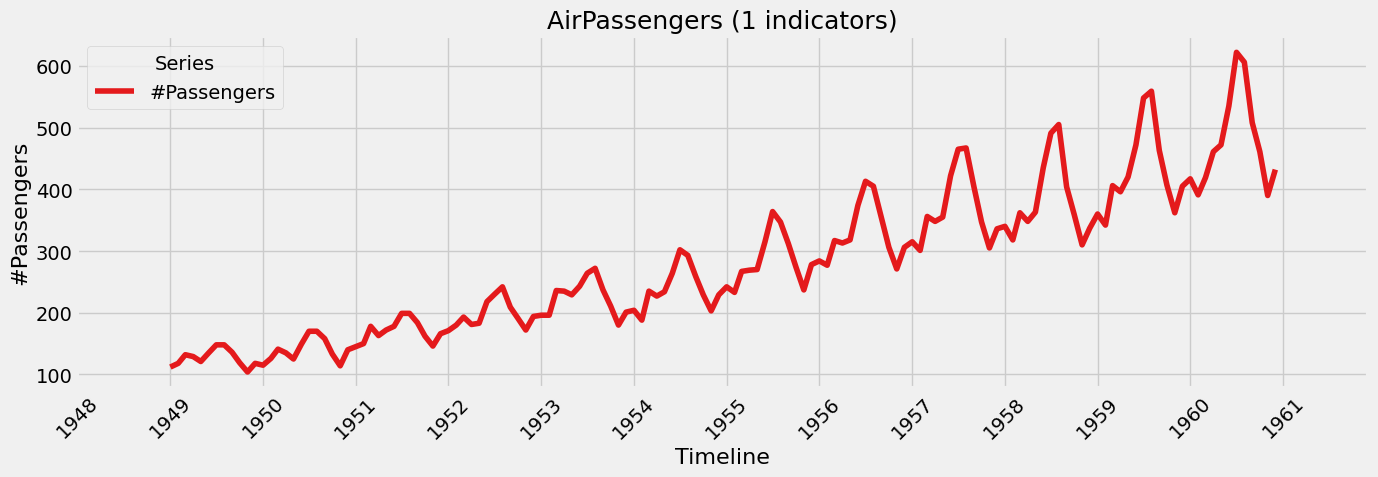

In [7]:
my_visualizer.plot_lines_chart(
    df,
    x_column="Month",
    y_columns=[value_column_name],
    title="AirPassengers",
    y_axis_title=value_column_name,
    y_unit="",
    prefix_figure_name="AirPassengers",
    marker=None,
)

## Divide data into train and test

In [8]:
train = df.iloc[: -int(len(df) * 0.2)]
test = df.iloc[-int(len(df) * 0.2) :]

In [9]:
train

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
111,1958-04-01,348
112,1958-05-01,363
113,1958-06-01,435
114,1958-07-01,491


In [10]:
test

,Month,#Passengers
116,1958-09-01,404
117,1958-10-01,359
118,1958-11-01,310
119,1958-12-01,337
120,1959-01-01,360
121,1959-02-01,342
122,1959-03-01,406
123,1959-04-01,396
124,1959-05-01,420
125,1959-06-01,472


## Fit the model

In [11]:
arima_model.fit(
    series=train[value_column_name], max_p=24, max_d=3, max_q=24, criterion="aic"
)

Searching ARIMA orders (parallelized): 100%|██████████| 2499/2499 [07:43<00:00,  5.40it/s]
d:\DATA SCIENCE\GIT\master-thesis\src\model\arima_model.py:54: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, nlags, crit = kpss(
d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [12]:
arima_model.get_order()

(15, 1, 0)

## Forecast

In [13]:
forecast = arima_model.forecast(steps=len(test))  # next 12 periods

In [14]:
forecast

116    442.674671
117    375.673441
118    334.117144
119    362.043851
120    366.809736
121    342.633068
122    378.652765
123    368.484140
124    383.364107
125    464.077680
126    516.640058
127    529.980854
128    473.675720
129    402.090024
130    362.779746
131    386.799006
132    390.499980
133    364.311468
134    393.095003
135    385.668370
136    401.602165
137    487.797288
138    538.747783
139    550.142081
140    500.825335
141    426.199775
142    389.127563
143    410.019991
Name: forecast, dtype: float64

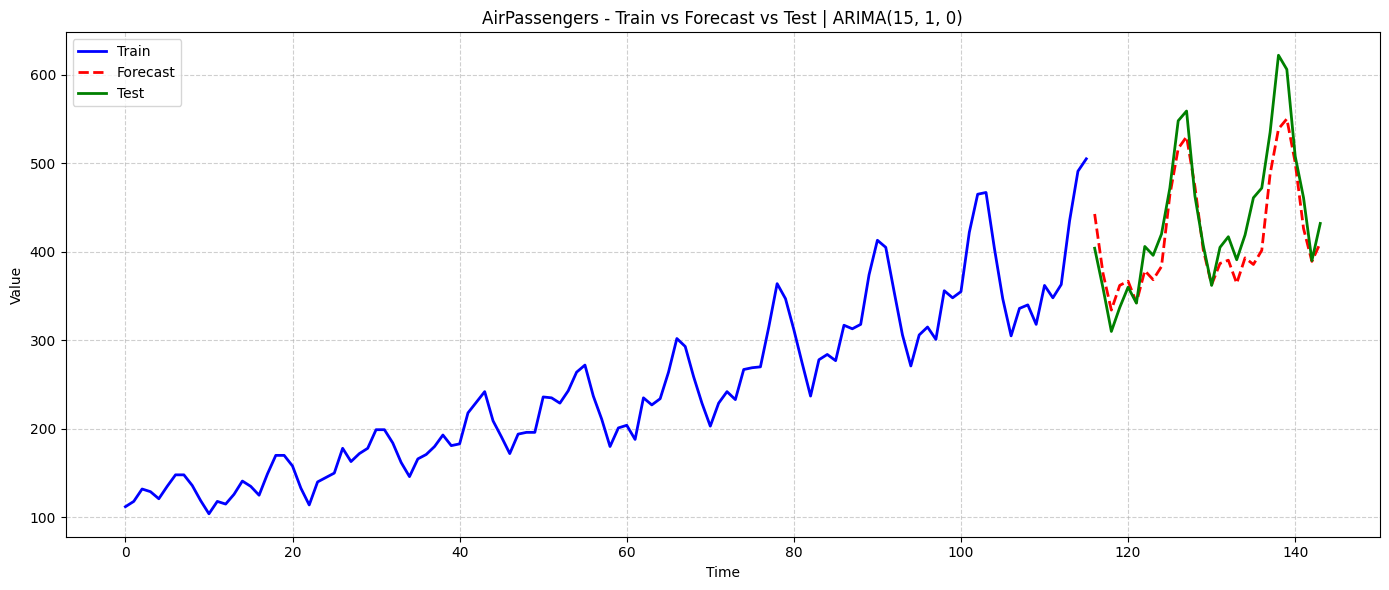

In [15]:
arima_model.plot_forecast(
    steps=len(test),
    test=test[value_column_name],
    title="AirPassengers - Train vs Forecast vs Test",
)